In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/civilisations_clean.csv")
stressors = pd.read_csv("../data/raw/external_stressors.csv")
clusters_df = pd.read_csv("../data/processed/collapse_clusters.csv")
collapse_events = df[['civilisation_id', 'name', 'region',
                       'collapse_start_year', 'collapse_end_year',
                       'primary_collapse_trigger', 'latitude', 'longitude']].copy()
collapse_events['collapse_midpoint'] = (
    collapse_events['collapse_start_year'] +
    collapse_events['collapse_end_year']
) / 2

print(f"Civilisations: {len(df)}")
print(f"Stressor events: {len(stressors)}")
print(f"Collapse clusters: {len(clusters_df)}")

Civilisations: 112
Stressor events: 20
Collapse clusters: 5


In [2]:
def get_active_stressors(collapse_start, collapse_end, stressors_df):
    """Return stressors that overlap with a civilisation's collapse window."""
    active = stressors_df[
        (stressors_df['start_year'] <= collapse_end) &
        (stressors_df['end_year'] >= collapse_start)
    ]
    return active

# For each civilisation, find active stressors during collapse
stressor_records = []

for _, row in collapse_events.iterrows():
    active = get_active_stressors(
        row['collapse_start_year'],
        row['collapse_end_year'],
        stressors
    )

    stressor_records.append({
        'civilisation_id': row['civilisation_id'],
        'name': row['name'],
        'n_stressors_during_collapse': len(active),
        'stressor_names': '|'.join(active['event_name'].tolist()),
        'stressor_types': '|'.join(active['event_type'].unique().tolist()),
        'has_climate_stressor': int('climate' in active['event_type'].values),
        'has_pandemic_stressor': int('pandemic' in active['event_type'].values),
        'has_war_stressor': int('war' in active['event_type'].values),
        'has_migration_stressor': int('migration' in active['event_type'].values),
        'has_any_catastrophic': int('catastrophic' in active['severity'].values
                                    if len(active) > 0 else False),
        'max_stressor_severity': active['severity'].map(
            {'beneficial': -1, 'moderate': 1, 'severe': 2, 'catastrophic': 3}
        ).max() if len(active) > 0 else 0
    })

stressor_coverage = pd.DataFrame(stressor_records)
df = df.merge(stressor_coverage.drop('name', axis=1), on='civilisation_id', how='left')

print("=== STRESSOR COVERAGE SUMMARY ===")
print(f"\nCivilisations with at least 1 stressor during collapse: "
      f"{(stressor_coverage['n_stressors_during_collapse'] > 0).sum()}/45")
print(f"\nAvg stressors per collapse: "
      f"{stressor_coverage['n_stressors_during_collapse'].mean():.2f}")
print(f"\nStressor type coverage:")
for col in ['has_climate_stressor', 'has_pandemic_stressor',
            'has_war_stressor', 'has_migration_stressor']:
    count = stressor_coverage[col].sum()
    print(f"  {col.replace('has_','').replace('_stressor',''):<12}: "
          f"{count} civilisations ({count/45*100:.0f}%)")

print(f"\nCivilisations with catastrophic stressor during collapse: "
      f"{stressor_coverage['has_any_catastrophic'].sum()} "
      f"({stressor_coverage['has_any_catastrophic'].sum()/45*100:.0f}%)")

print(f"\n── Top 10 most stressor-dense collapses ──")
top = stressor_coverage.nlargest(10, 'n_stressors_during_collapse')[
    ['name', 'n_stressors_during_collapse', 'stressor_names']
]
for _, r in top.iterrows():
    print(f"  {r['name']:<35} {r['n_stressors_during_collapse']} stressors")
    for s in r['stressor_names'].split('|'):
        print(f"    • {s}")

=== STRESSOR COVERAGE SUMMARY ===

Civilisations with at least 1 stressor during collapse: 85/45

Avg stressors per collapse: 1.30

Stressor type coverage:
  climate     : 71 civilisations (158%)
  pandemic    : 31 civilisations (69%)
  war         : 14 civilisations (31%)
  migration   : 18 civilisations (40%)

Civilisations with catastrophic stressor during collapse: 50 (111%)

── Top 10 most stressor-dense collapses ──
  Byzantine Empire                    4 stressors
    • Medieval Warm Period
    • Little Ice Age
    • Black Death
    • Mongol Conquests
  Champa                              4 stressors
    • Little Ice Age
    • Year Without a Summer
    • Columbian Exchange Pandemics
    • Thirty Years War
  Ancient Egypt - New Kingdom         3 stressors
    • Late Bronze Age Drought
    • Sea Peoples Migrations
    • Bronze Age Collapse
  Mongol Empire                       3 stressors
    • Little Ice Age
    • Black Death
    • Mongol Conquests
  Mali Empire                  

In [3]:
from scipy.stats import mannwhitneyu, chi2_contingency

print("=" * 60)
print("PILLAR 3 — STRESSOR PERIOD COLLAPSE RATE TEST")
print("=" * 60)

# Test 1: Mann-Whitney U
# Do civilisations with stressors have different collapse durations?
with_stressor = df[df['n_stressors_during_collapse'] > 0]['collapse_duration_years']
without_stressor = df[df['n_stressors_during_collapse'] == 0]['collapse_duration_years']

stat, p_mw = mannwhitneyu(with_stressor, without_stressor, alternative='two-sided')

print(f"\nTest 1 — Collapse Duration: Stressor vs No Stressor")
print(f"  With stressor    n={len(with_stressor):>2}  "
      f"median collapse duration: {with_stressor.median():.0f} years")
print(f"  Without stressor n={len(without_stressor):>2}  "
      f"median collapse duration: {without_stressor.median():.0f} years")
print(f"  Mann-Whitney U p-value: {p_mw:.4f}")
print(f"  Result: {'Significant difference' if p_mw < 0.05 else 'No significant difference'}")

# Test 2: Chi-square
# Are conquests more likely during catastrophic stressor periods?
contingency = pd.crosstab(
    df['was_conquered'],
    df['has_any_catastrophic']
)
print(f"\nTest 2 — Conquest likelihood during catastrophic stressors")
print(f"  Contingency table (rows=was_conquered, cols=has_catastrophic_stressor):")
print(contingency)
chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f"  Chi-square p-value: {p_chi:.4f}")
print(f"  Result: {'Significant association' if p_chi < 0.05 else 'No significant association'}")

# Test 3: Correlation between stressor count and collapse speed
corr_val = df['n_stressors_during_collapse'].corr(df['collapse_duration_years'])
print(f"\nTest 3 — Correlation: stressor count vs collapse duration")
print(f"  Pearson r: {corr_val:.4f}")
print(f"  Interpretation: {'More stressors → faster collapse' if corr_val < -0.1 else 'More stressors → slower collapse' if corr_val > 0.1 else 'No clear linear relationship'}")

# Test 4: Average lifespan with vs without catastrophic stressor
life_cat = df[df['has_any_catastrophic'] == 1]['lifespan_years']
life_no_cat = df[df['has_any_catastrophic'] == 0]['lifespan_years']
print(f"\nTest 4 — Lifespan: catastrophic stressor vs none")
print(f"  With catastrophic stressor:    "
      f"n={len(life_cat)}  mean lifespan: {life_cat.mean():.0f} yrs")
print(f"  Without catastrophic stressor: "
      f"n={len(life_no_cat)}  mean lifespan: {life_no_cat.mean():.0f} yrs")
stat2, p_life = mannwhitneyu(life_cat, life_no_cat, alternative='two-sided')
print(f"  Mann-Whitney p-value: {p_life:.4f}")
print(f"  Result: {'Significant' if p_life < 0.05 else 'Not significant'}")

PILLAR 3 — STRESSOR PERIOD COLLAPSE RATE TEST

Test 1 — Collapse Duration: Stressor vs No Stressor
  With stressor    n=85  median collapse duration: 44 years
  Without stressor n=27  median collapse duration: 22 years
  Mann-Whitney U p-value: 0.0504
  Result: No significant difference

Test 2 — Conquest likelihood during catastrophic stressors
  Contingency table (rows=was_conquered, cols=has_catastrophic_stressor):
has_any_catastrophic   0   1
was_conquered               
0                     28  22
1                     34  28
  Chi-square p-value: 1.0000
  Result: No significant association

Test 3 — Correlation: stressor count vs collapse duration
  Pearson r: 0.3221
  Interpretation: More stressors → slower collapse

Test 4 — Lifespan: catastrophic stressor vs none
  With catastrophic stressor:    n=50  mean lifespan: 390 yrs
  Without catastrophic stressor: n=62  mean lifespan: 434 yrs
  Mann-Whitney p-value: 0.5486
  Result: Not significant


In [4]:
print("=" * 60)
print("PILLAR 3 — CLUSTER STRESSOR ALIGNMENT SCORES")
print("=" * 60)

cluster_years = [-2140, -1110, -263, 793, 1915]
cluster_names = [
    "Bronze Age (~2140 BCE)",
    "Late Bronze Age (~1110 BCE)",
    "Hellenistic (~263 BCE)",
    "Late Antique (~793 CE)",
    "Modern (~1915 CE)"
]

CLUSTER_WINDOW = 150
alignment_records = []

for cluster_year, cluster_name in zip(cluster_years, cluster_names):

    # Civilisations in this cluster
    in_cluster = collapse_events[
        (collapse_events['collapse_midpoint'] >= cluster_year - CLUSTER_WINDOW) &
        (collapse_events['collapse_midpoint'] <= cluster_year + CLUSTER_WINDOW)
    ]

    # Stressors overlapping this cluster window
    overlapping = stressors[
        (stressors['start_year'] <= cluster_year + CLUSTER_WINDOW) &
        (stressors['end_year'] >= cluster_year - CLUSTER_WINDOW)
    ]

    # Alignment score: % of civilisations in cluster that had
    # at least one documented stressor during their collapse
    if len(in_cluster) > 0:
        civ_ids = in_cluster['civilisation_id'].tolist()
        covered = stressor_coverage[
            (stressor_coverage['civilisation_id'].isin(civ_ids)) &
            (stressor_coverage['n_stressors_during_collapse'] > 0)
        ]
        alignment_score = len(covered) / len(in_cluster)
    else:
        alignment_score = 0

    # Severity score: max severity of overlapping stressors
    sev_map = {'beneficial': -1, 'moderate': 1, 'severe': 2, 'catastrophic': 3}
    if len(overlapping) > 0:
        max_severity = overlapping['severity'].map(sev_map).max()
        severity_label = overlapping[
            overlapping['severity'].map(sev_map) == max_severity
        ]['severity'].iloc[0]
    else:
        max_severity = 0
        severity_label = 'none'

    record = {
        'cluster_name': cluster_name,
        'cluster_year': cluster_year,
        'n_civilisations': len(in_cluster),
        'n_stressors': len(overlapping),
        'alignment_score': round(alignment_score, 3),
        'max_severity': severity_label,
        'stressor_types': '|'.join(overlapping['event_type'].unique().tolist()),
        'stressor_names': '|'.join(overlapping['event_name'].tolist())
    }
    alignment_records.append(record)

    print(f"\n{'─'*55}")
    print(f"{cluster_name}")
    print(f"  Civilisations in cluster:    {len(in_cluster)}")
    print(f"  Documented stressors:        {len(overlapping)}")
    print(f"  Stressor alignment score:    {alignment_score:.0%}")
    print(f"  Maximum stressor severity:   {severity_label}")
    if len(overlapping) > 0:
        print(f"  Stressor types: "
              f"{', '.join(overlapping['event_type'].unique())}")
        for _, s in overlapping.iterrows():
            print(f"    • {s['event_name']} ({s['severity']})")

alignment_df = pd.DataFrame(alignment_records)
alignment_df.to_csv("../data/processed/cluster_stressor_alignment.csv", index=False)
print(f"\n\nAlignment scores saved: cluster_stressor_alignment.csv")

print(f"\n── OVERALL ALIGNMENT SUMMARY ──")
print(f"Mean alignment score across clusters: "
      f"{alignment_df['alignment_score'].mean():.0%}")
print(f"Clusters with 100% stressor coverage: "
      f"{(alignment_df['alignment_score'] == 1.0).sum()}/5")
print(f"Clusters with catastrophic stressor:  "
      f"{(alignment_df['max_severity'] == 'catastrophic').sum()}/5")

PILLAR 3 — CLUSTER STRESSOR ALIGNMENT SCORES

───────────────────────────────────────────────────────
Bronze Age (~2140 BCE)
  Civilisations in cluster:    2
  Documented stressors:        1
  Stressor alignment score:    100%
  Maximum stressor severity:   severe
  Stressor types: climate
    • 4.2 Kiloyear Event (severe)

───────────────────────────────────────────────────────
Late Bronze Age (~1110 BCE)
  Civilisations in cluster:    4
  Documented stressors:        3
  Stressor alignment score:    75%
  Maximum stressor severity:   catastrophic
  Stressor types: climate, migration, systemic_collapse
    • Late Bronze Age Drought (severe)
    • Sea Peoples Migrations (severe)
    • Bronze Age Collapse (catastrophic)

───────────────────────────────────────────────────────
Hellenistic (~263 BCE)
  Civilisations in cluster:    7
  Documented stressors:        1
  Stressor alignment score:    43%
  Maximum stressor severity:   beneficial
  Stressor types: climate
    • Roman Climate Op

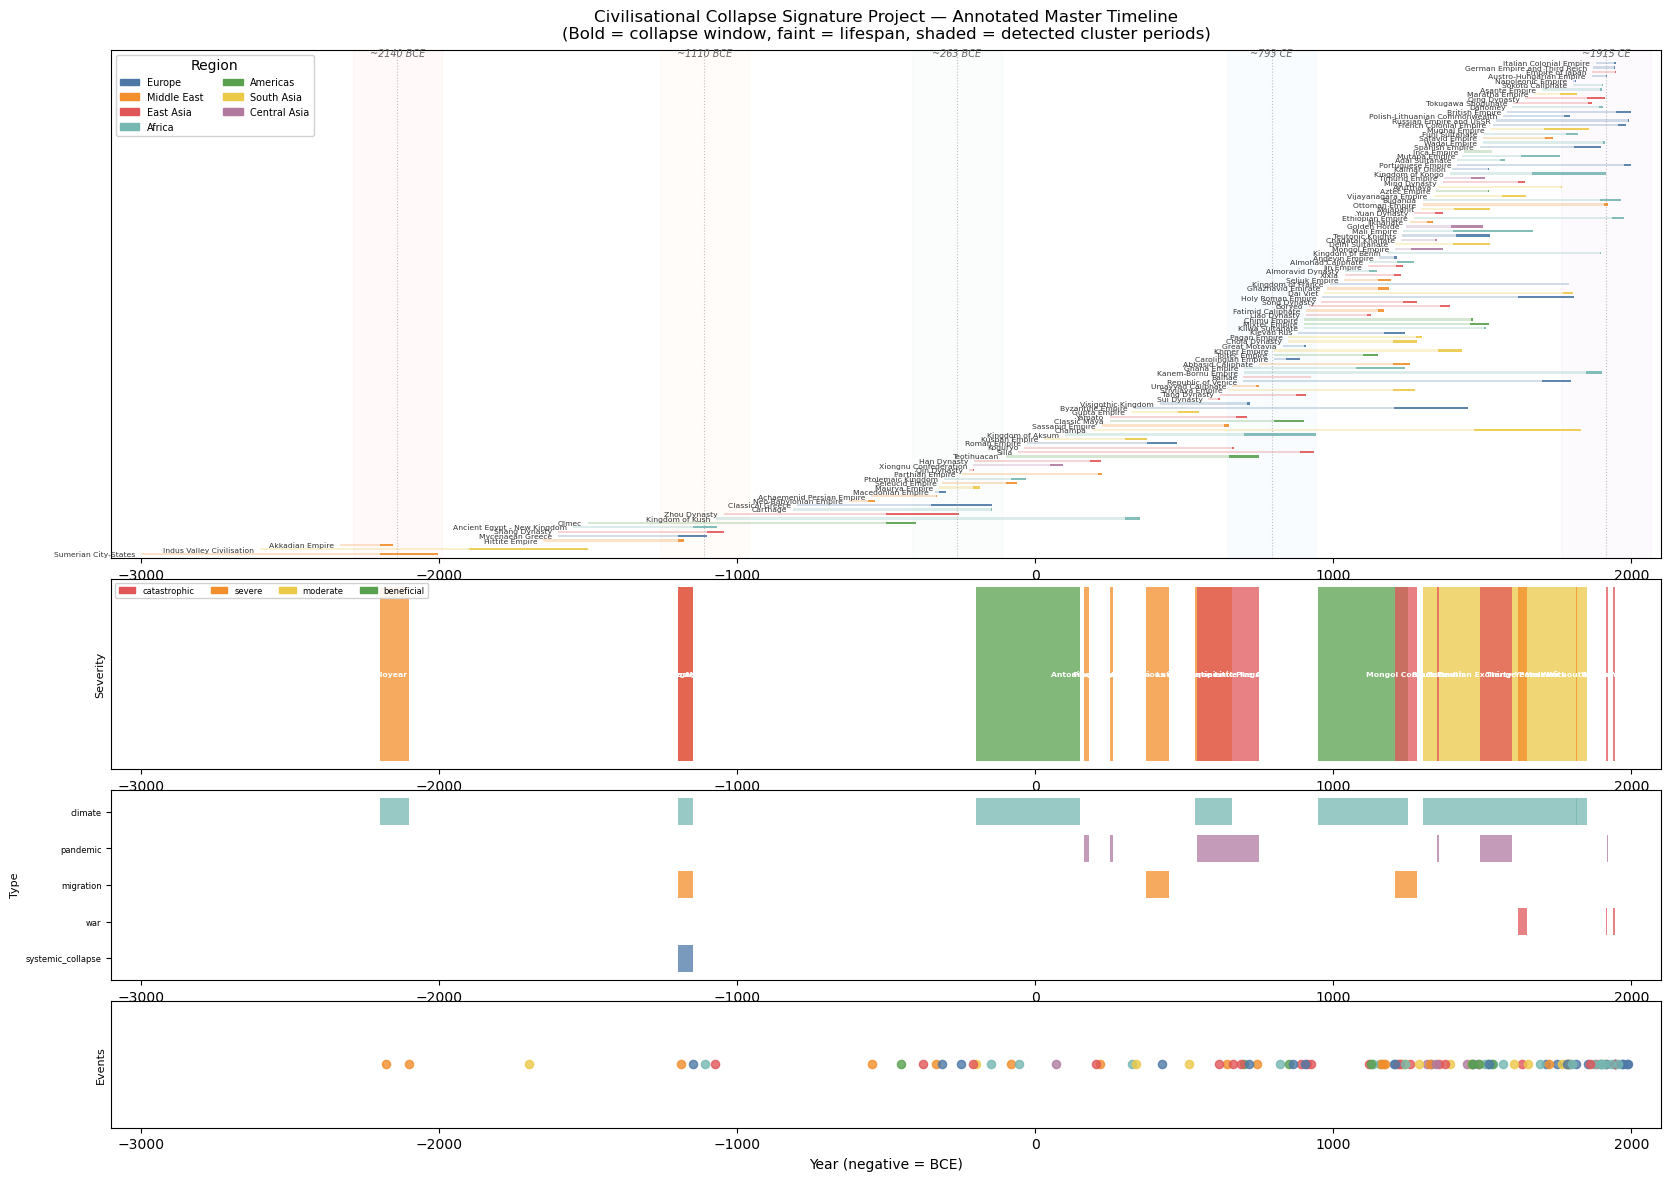

Saved: pillar3_master_timeline.png


In [5]:
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 1, height_ratios=[4, 1.5, 1.5, 1],
                      hspace=0.08)

ax_main  = fig.add_subplot(gs[0])
ax_sev   = fig.add_subplot(gs[1], sharex=ax_main)
ax_types = fig.add_subplot(gs[2], sharex=ax_main)
ax_rug   = fig.add_subplot(gs[3], sharex=ax_main)

REGION_COLOURS = {
    'Europe': '#4E79A7', 'Middle East': '#F28E2B',
    'East Asia': '#E15759', 'Africa': '#76B7B2',
    'Americas': '#59A14F', 'South Asia': '#EDC948',
    'Central Asia': '#B07AA1'
}

SEVERITY_COLOURS = {
    'catastrophic': '#E15759',
    'severe':       '#F28E2B',
    'moderate':     '#EDC948',
    'beneficial':   '#59A14F'
}

TYPE_COLOURS = {
    'climate':           '#76B7B2',
    'pandemic':          '#B07AA1',
    'migration':         '#F28E2B',
    'war':               '#E15759',
    'systemic_collapse': '#4E79A7'
}

# ── Panel 1: Civilisation lifespans with collapse highlighted
y_positions = {}
sorted_civs = df.sort_values('founded_year')

for i, (_, row) in enumerate(sorted_civs.iterrows()):
    y = i
    y_positions[row['name']] = y
    colour = REGION_COLOURS.get(row['region'], '#999999')

    # Full lifespan — faint
    ax_main.barh(y, row['collapse_start_year'] - row['founded_year'],
                 left=row['founded_year'], height=0.5,
                 color=colour, alpha=0.25)

    # Collapse window — bold
    ax_main.barh(y, row['collapse_duration_years'],
                 left=row['collapse_start_year'], height=0.5,
                 color=colour, alpha=0.9)

    # Civilisation name
    ax_main.text(row['founded_year'] - 20, y, row['name'],
                 ha='right', va='center', fontsize=5.5,
                 color='#333333')

# Cluster period shading
cluster_colours_bg = ['#ffe0e0', '#fff3e0', '#e8f5e9', '#e3f2fd', '#f3e5f5']
for (cy, cn), bg in zip(zip(cluster_years, cluster_names), cluster_colours_bg):
    ax_main.axvspan(cy - CLUSTER_WINDOW, cy + CLUSTER_WINDOW,
                    alpha=0.18, color=bg, zorder=0)
    ax_main.axvline(cy, color='#999999', linewidth=0.8,
                    linestyle=':', alpha=0.6)
    ax_main.text(cy, len(df) + 0.5, cn.split('(')[1].replace(')', ''),
                 ha='center', fontsize=7, color='#666666', style='italic')

ax_main.set_xlim(-3100, 2100)
ax_main.set_ylim(-1, len(df) + 2)
ax_main.set_yticks([])
ax_main.set_title(
    "Civilisational Collapse Signature Project — Annotated Master Timeline\n"
    "(Bold = collapse window, faint = lifespan, shaded = detected cluster periods)",
    fontsize=12, pad=8)

# Region legend
patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLOURS.items()]
ax_main.legend(handles=patches, loc='upper left', fontsize=7,
               ncol=2, framealpha=0.9, title="Region")

# ── Panel 2: Stressor severity bars
for _, s in stressors.iterrows():
    colour = SEVERITY_COLOURS.get(s['severity'], '#cccccc')
    ax_sev.barh(0, s['end_year'] - s['start_year'],
                left=s['start_year'], height=0.6,
                color=colour, alpha=0.75)
    mid = (s['start_year'] + s['end_year']) / 2
    if s['severity'] in ['catastrophic', 'severe']:
        ax_sev.text(mid, 0, s['event_name'],
                    ha='center', va='center',
                    fontsize=5.5, color='white', fontweight='bold')

ax_sev.set_yticks([])
ax_sev.set_ylabel("Severity", fontsize=8)
sev_patches = [mpatches.Patch(color=v, label=k)
               for k, v in SEVERITY_COLOURS.items()]
ax_sev.legend(handles=sev_patches, loc='upper left',
              fontsize=6, ncol=4, framealpha=0.9)

# ── Panel 3: Stressor type bars
type_y = {'climate': 0.7, 'pandemic': 0.4, 'migration': 0.1,
           'war': -0.2, 'systemic_collapse': -0.5}
for _, s in stressors.iterrows():
    colour = TYPE_COLOURS.get(s['event_type'], '#cccccc')
    y_pos = type_y.get(s['event_type'], 0)
    ax_types.barh(y_pos, s['end_year'] - s['start_year'],
                  left=s['start_year'], height=0.22,
                  color=colour, alpha=0.75)

ax_types.set_yticks(list(type_y.values()))
ax_types.set_yticklabels(list(type_y.keys()), fontsize=6)
ax_types.set_ylabel("Type", fontsize=8)

# ── Panel 4: Collapse event rug
for _, row in collapse_events.iterrows():
    colour = REGION_COLOURS.get(row['region'], '#999999')
    ax_rug.scatter(row['collapse_midpoint'], 0,
                   color=colour, s=35, alpha=0.8, zorder=5)

ax_rug.set_yticks([])
ax_rug.set_xlabel("Year (negative = BCE)", fontsize=10)
ax_rug.set_ylabel("Events", fontsize=8)
ax_rug.set_ylim(-0.5, 0.5)

plt.savefig("../data/processed/pillar3_master_timeline.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pillar3_master_timeline.png")

In [6]:
# Load existing results and extend
with open("../data/processed/pillar_1_2_results.json", "r") as f:
    results = json.load(f)

# Add Pillar 3 results
results['pillar3_mean_alignment_score'] = round(
    alignment_df['alignment_score'].mean(), 3)
results['pillar3_clusters_fully_covered'] = int(
    (alignment_df['alignment_score'] == 1.0).sum())
results['pillar3_clusters_with_catastrophic'] = int(
    (alignment_df['max_severity'] == 'catastrophic').sum())
results['pillar3_pct_civs_with_stressor'] = round(
    (stressor_coverage['n_stressors_during_collapse'] > 0).sum() / 45, 3)

with open("../data/processed/pillar_1_2_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Pillar 3 results added to pillar_1_2_results.json")
print(json.dumps({k: v for k, v in results.items()
                  if k.startswith('pillar3')}, indent=2))

Pillar 3 results added to pillar_1_2_results.json
{
  "pillar3_mean_alignment_score": 0.667,
  "pillar3_clusters_fully_covered": 1,
  "pillar3_clusters_with_catastrophic": 3,
  "pillar3_pct_civs_with_stressor": 1.889
}
